In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [3]:
platform_counts = df['job_via'].value_counts().head(5)

platform_counts

,count
job_via,
via LinkedIn,186679
via BeBee,103507
via Trabajo.org,61562
via Indeed,42756
via Recruit.net,23646


Text(0, 0.5, 'Count of Platforms')

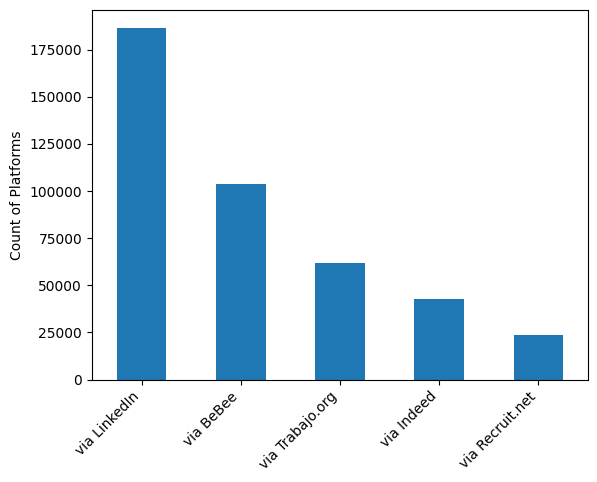

In [6]:
platform_counts.plot(kind='bar')
plt.xticks(rotation=45 , ha='right')
plt.xlabel('')
plt.ylabel('Count of Platforms')

In [8]:
location_count = df['job_location'].value_counts().head(5)
location_count

,count
job_location,
Anywhere,69552
Singapore,23415
"Paris, France",12311
"Bengaluru, Karnataka, India",11474
"London, UK",10564


Text(0.5, 1.0, 'Number of Job Postings by Job Location')

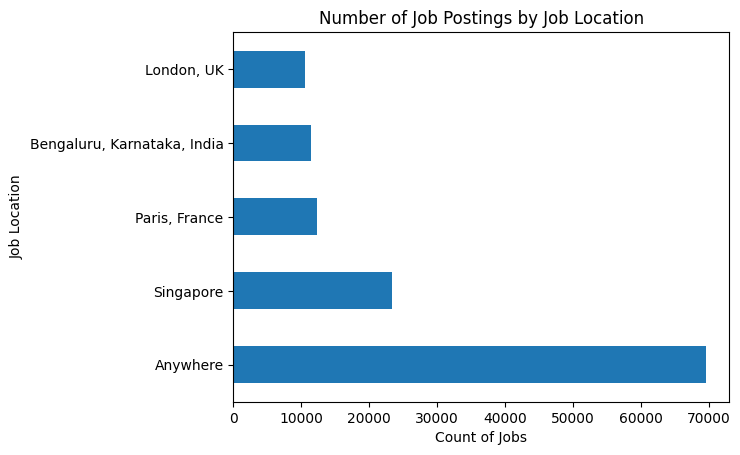

In [9]:
location_count.plot(kind='barh')
plt.xlabel('Count of Jobs')
plt.ylabel('Job Location')
plt.title('Number of Job Postings by Job Location')


In [24]:
df['job_posted_month'] = df['job_posted_date'].dt.month

In [26]:
new_df = df['job_posted_month'].value_counts().sort_index()
new_df

,count
job_posted_month,
1,91822
2,64578
3,64084
4,62919
5,52104
6,61572
7,63777
8,75162
9,62359


In [28]:
new_df = pd.Series(new_df.values , index=['Jan', 'Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Okt','Nov','Dec'])

In [29]:
new_df

,0
Jan,91822
Feb,64578
Mar,64084
Apr,62919
May,52104
Jun,61572
Jul,63777
Aug,75162
Sep,62359
Okt,66611


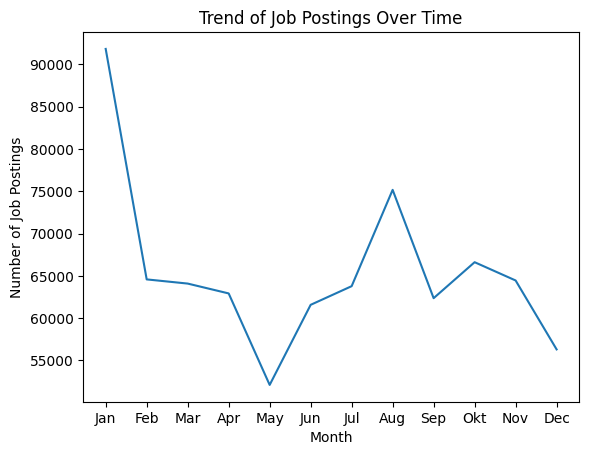

In [31]:
new_df.plot(kind='line')
plt.xticks(ticks=range(len(new_df)), labels=new_df.index)
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.title('Trend of Job Postings Over Time')
plt.show()

In [32]:
df['Job_month'] = df['job_posted_date'].dt.to_period('M')

monthly_counts = df['Job_month'].value_counts().sort_index()

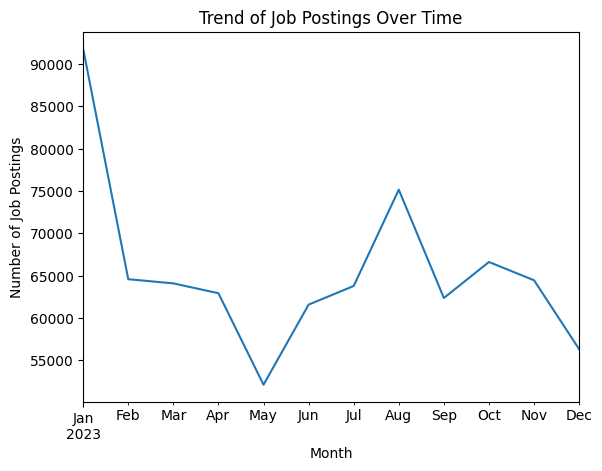

In [34]:
monthly_counts.plot(kind='line')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.title('Trend of Job Postings Over Time')
plt.show()